In [5]:
# Transformers example -> Reverseing sequence of numbers


In [1]:
import haiku as hk
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np
import optax

from probjax.nn.transformers import Transformer
from sbi.analysis import pairplot

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
jax.devices()

[CpuDevice(id=0)]

In [3]:
def generate_data(key, n):
    key1, key2, key3 = jrandom.split(key,3)
    theta1 = jrandom.normal(key1, (n, 1))  * 3
    x1 = 2*jnp.sin(theta1) + jrandom.normal(key2, (n, 1)) * 0.5
    #x3 = theta1 + jrandom.normal(key2, (n, 1)) * 0.5
    # x2 = 2*jnp.sin(theta1) + jrandom.normal(key3, (n, 1)) * 0.1
    # x2 = .3*theta1 + 10 + jrandom.normal(key, (n, 1))
    # x3 = jnp.sin(theta1) + jrandom.normal(key, (n, 1))
    # x4 = jnp.cos(theta1) + jrandom.normal(key, (n, 1))
    return jnp.concatenate([theta1,x1], axis=1).reshape(n, -1, 1)


data = generate_data(jrandom.PRNGKey(1), 10000)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

node_ids = jnp.arange(T_max)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

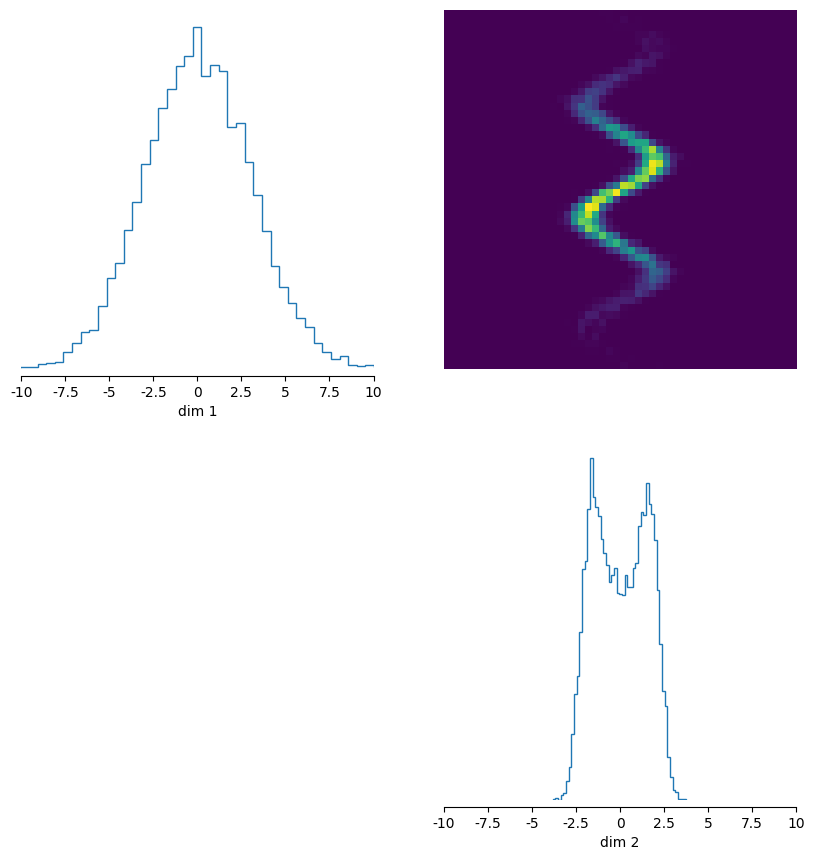

In [4]:
pairplot(np.array(data[:, :, 0]), limits=[[-10, 10], [-10, 10], [-10, 10]])

In [5]:
key = jrandom.PRNGKey(0)

In [6]:
from probjax.distributions import Independent, Normal
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.nn.bijective import rational_quadratic_spline
from probjax.nn.helpers import rotate

In [7]:

@jax.vmap
def bijector(params, x):
    return rational_quadratic_spline(params, x, range_min_x=-10, range_max_x=10,range_min_y = -15., range_max_y=15.)

num_bins = 50
bijector_dim = 3 * num_bins

num_transforms = 4

In [93]:

def model(node_ids, node_values, condition_mask):

    node_ids = node_ids.astype(jnp.int32)
    node_ids = jnp.reshape(node_ids, (-1, T_max, 1))
    node_values = jnp.reshape(node_values, (-1, T_max, 1))
    condition_mask = jnp.reshape(condition_mask, (-1, T_max, 1)).astype(jnp.bool_)

    dim = 40
    _dim = int(dim) // 2

    embed_node_ids = hk.Embed(T_max, _dim)
    embed_node_values = hk.nets.MLP([dim,dim, _dim])
    condtion_embedding = hk.get_parameter("condtion_embedding", shape=[1,1, dim], dtype=jnp.float32, init=hk.initializers.RandomNormal(10.))


    model = Transformer(num_heads=1, num_layers=5, attn_size=dim, dropout_rate=None)

    embedding_node_ids = embed_node_ids(node_ids)
    embedding_node_ids = jnp.reshape(embedding_node_ids, (-1, T_max, _dim))
    embedding_node_values = embed_node_values(node_values)
    embedding_node_values = jnp.reshape(embedding_node_values, (-1, T_max, _dim))

    embedding_node_ids = jnp.broadcast_to(embedding_node_ids, embedding_node_values.shape)

    x_encoded = jnp.concatenate([embedding_node_ids, embedding_node_values], axis=-1)
    x_encoded = x_encoded + condtion_embedding * condition_mask


    h = model(x_encoded)

    h1 = hk.nets.MLP([dim, bijector_dim])(h)
    h2 = hk.nets.MLP([dim, bijector_dim])(h)
    h3 = hk.nets.MLP([dim, bijector_dim])(h)
    h4 = hk.nets.MLP([dim, bijector_dim])(h)

    rot1 = hk.nets.MLP([dim, T_max])(h).reshape(-1, T_max, T_max)
    rot2 = hk.nets.MLP([dim, T_max])(h).reshape(-1, T_max, T_max)
    rot3 = hk.nets.MLP([dim, T_max])(h).reshape(-1, T_max, T_max)
    rot1 = jnp.linalg.qr(rot1)[0]
    rot2 = jnp.linalg.qr(rot2)[0]
    rot3 = jnp.linalg.qr(rot3)[0]

    return h1, rot1, h2, rot2, h3, rot3, h4


In [94]:
init, model_fn = hk.transform(model)

params = init(key, node_ids, jnp.zeros((1,2,1)), jnp.array([0, 0]))
out = model_fn(params, key, node_ids, jnp.zeros((10,2,1)), jnp.zeros((10,2,1), dtype=int))

In [104]:


def transform_params(node_ids, node_values, params):
    bij_params1, rot1, bij_params2, rot2, bij_params3, rot3, bij_params4 = model_fn(params, key, node_ids, node_values, jnp.array([0, 0]))
    bij_params1 = jnp.squeeze(bij_params1)
    bij_params2 = jnp.squeeze(bij_params2)
    bij_params3 = jnp.squeeze(bij_params3)
    bij_params4 = jnp.squeeze(bij_params4)
    rot1 = jnp.squeeze(rot1)
    rot2 = jnp.squeeze(rot2)
    rot3 = jnp.squeeze(rot3)
    return bij_params1, rot1, bij_params2, rot2, bij_params3, rot3, bij_params4

def transform(x, bij_params1, rot1, bij_params2, rot2, bij_params3, rot3, bij_params4):


    x1 = bijector(bij_params1, x)
    x2 = rotate(rot1, x1)
    x3 = bijector(bij_params2, x2)
    x4 = rotate(rot2, x3)
    x5 = bijector(bij_params3, x4)
    x6 = rotate(rot3, x5)
    x7 = bijector(bij_params4, x6)

    return x7

p0 = Independent(Normal(jnp.zeros((2,)), jnp.ones((2,))), 2)

bij_params = transform_params(node_ids, jnp.zeros((1,2,1)), params)
p = TransformedDistribution(p0, lambda x: transform(x, *bij_params))

samples = p.sample(key, (10,))
log_prob = p.log_prob(samples)

[True, False] [True] 1
[True, False] [True] 1
[True, False] [True] 1
[True, False] [True] 1
[True, False] [True] 1
[True, False] [True] 1
[True, False] [True] 1
[True, False] [True] 1


In [67]:
f = lambda x: transform(x,node_ids, params)

In [68]:
optimizer = optax.adam(5e-4)
opt_state = optimizer.init(params)

In [105]:
@jax.jit
def loss_fn(params, key, batch_size= 512):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)

    # Generate data
    batch_xs = generate_data(rng_data, batch_size) # n, T_max, 1

    # Generate condition mask
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0,0], [1,0], [0,1]]), shape=(1,), p=jnp.array([0.33, 0.33, 0.33]), axis=0)
    condition_mask = condition_mask[..., None]

    # Permute sequence -> randomly permute the sequence of data to promote node identification
    node_values = jnp.zeros_like(batch_xs) + condition_mask * batch_xs

    p0 = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)
    bij_params = transform_params(node_ids, node_values, params)
    p = TransformedDistribution(p0, lambda x: transform(x,*bij_params))

    loss = -jnp.mean(p.log_prob(jnp.squeeze(batch_xs, -1)))
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [106]:
# This takes forever to compile ... Probably due to splines with vmap -> Actually no, probably due to transformer also getting transformation as input
_ = update(params, key, opt_state)

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 512: axis 0 of argument params of type float32[512,2,150];
  * one axis had size 2: axis 0 of argument x of type float32[2]

In [74]:
for _ in range(5):
    for i in range(1000):
        key = jrandom.PRNGKey(i+1000)
        loss, params, opt_state = update(params, key, opt_state)
        if i % 500 == 0:
            print(loss)

11.268678
3.4361496
3.3838942


KeyboardInterrupt: 

In [77]:

def sample_fn(key, shape, node_ids=node_ids, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    p0 = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)
    bij_params = transform_params(node_ids, jnp.zeros_like(node_ids), params)
    p = TransformedDistribution(p0, lambda x: transform(x,*bij_params))
    return p.sample(key, shape)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

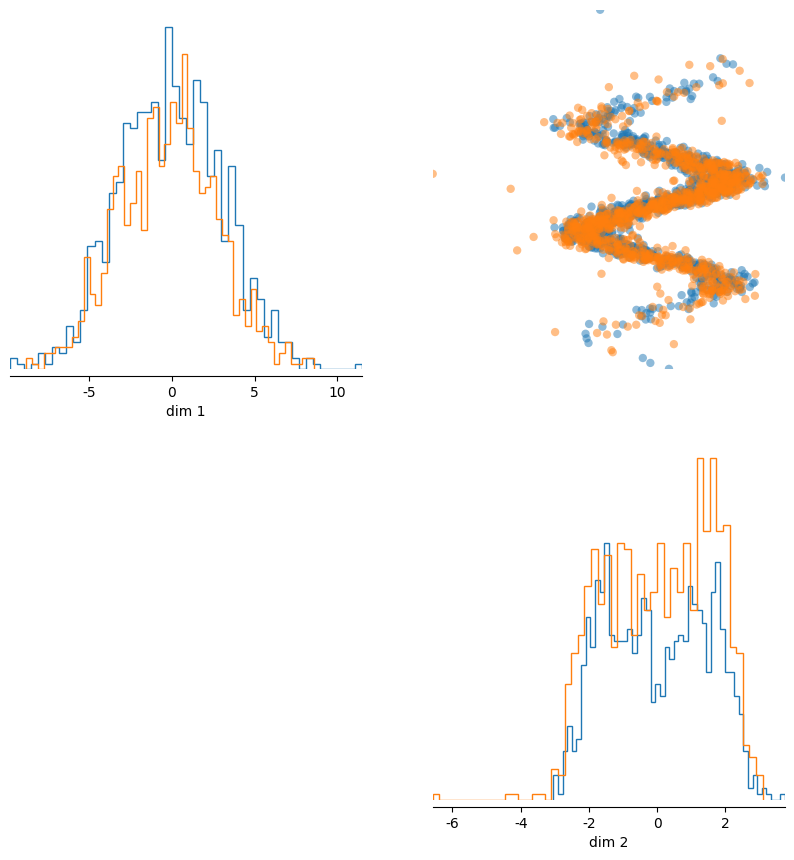

In [78]:

samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids)
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,:])], upper="scatter")

2


(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

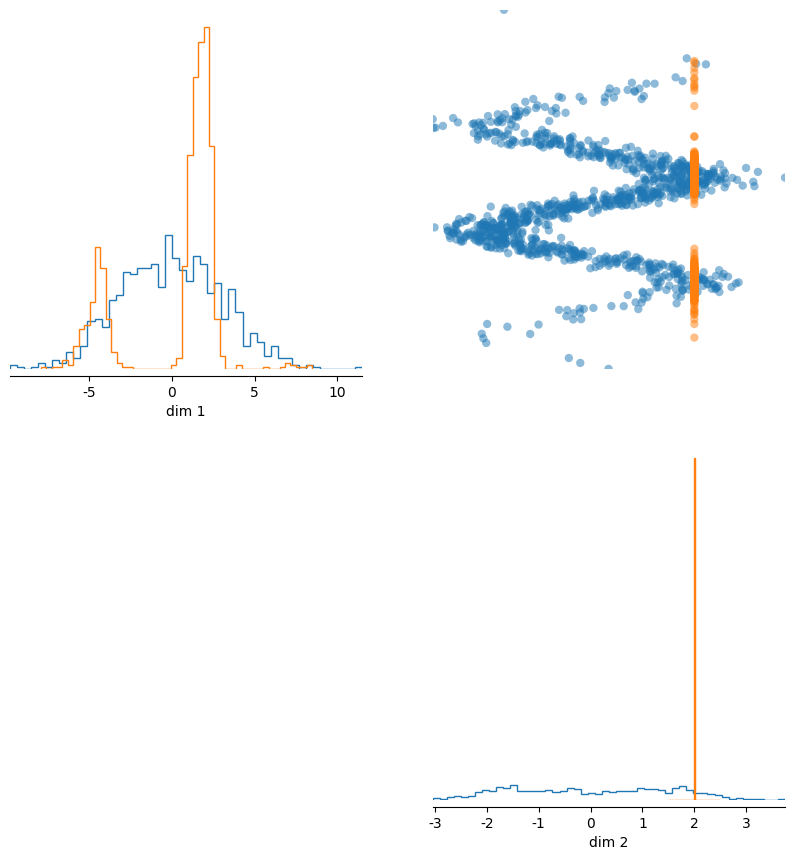

In [72]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

2


(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

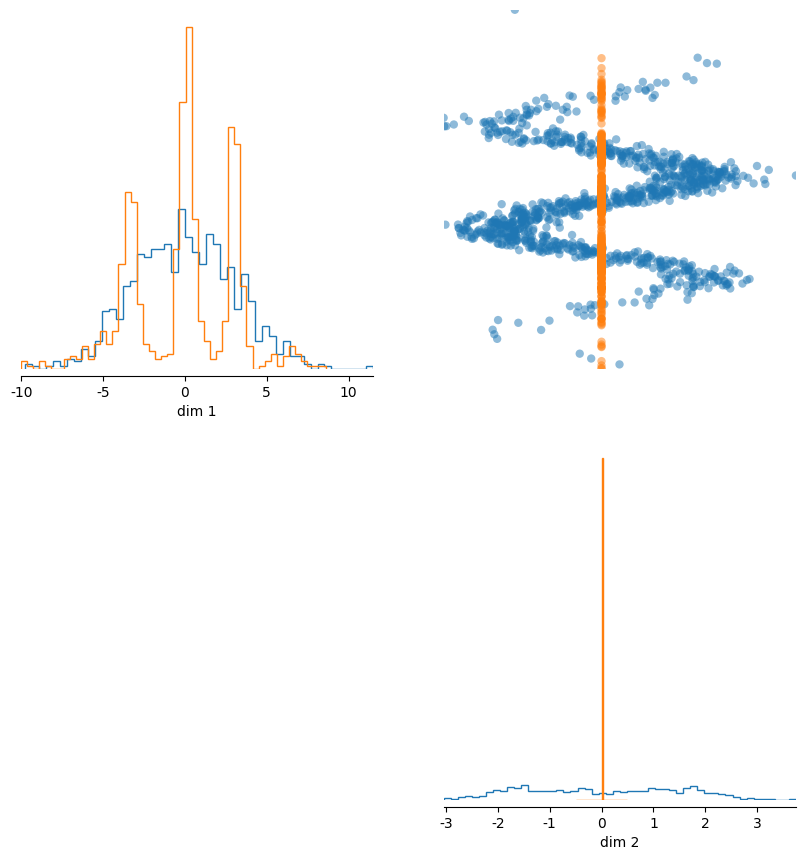

In [73]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 0.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

2


(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

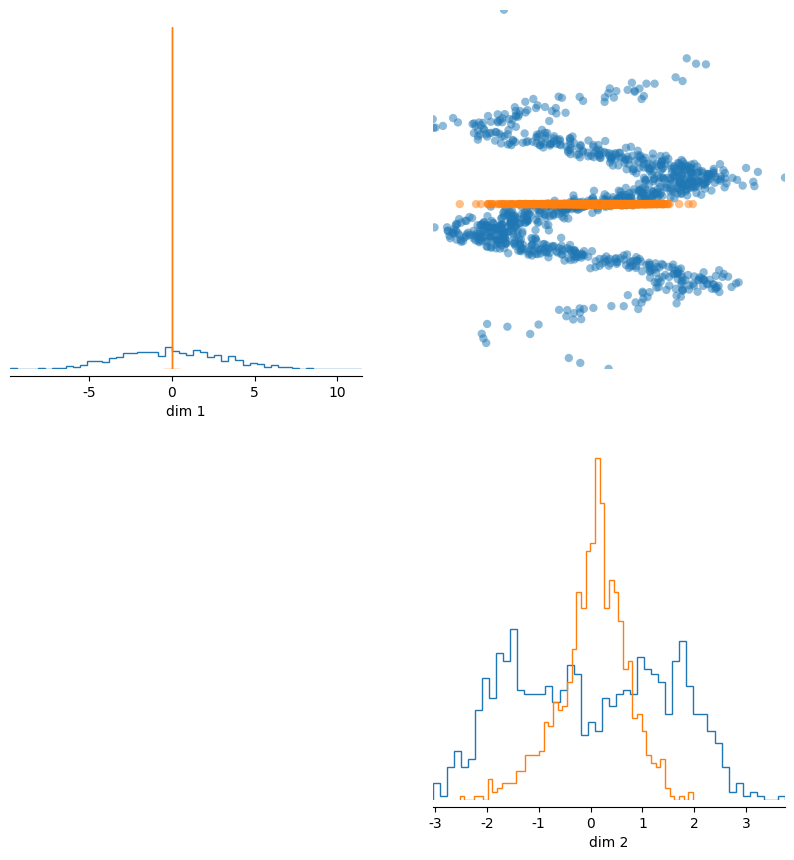

In [74]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([1,0]), condition_value=jnp.array([0., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

2


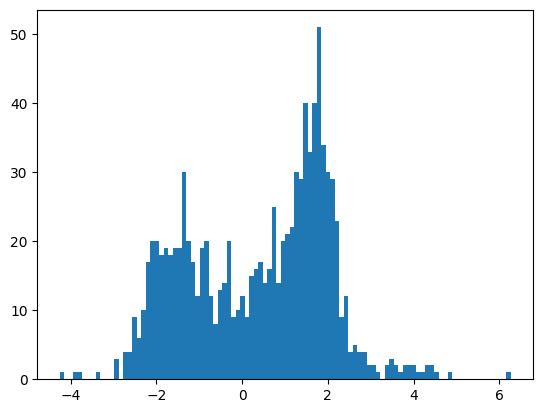

In [225]:
import numpy as np

from sbi.analysis import pairplot

condition_mask = jnp.array([0,0])

samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=jnp.array([1]))
_ = plt.hist(np.array(samples[...,-1, 1]).flatten(), bins=100)